<a href="https://colab.research.google.com/github/fboldt/aulas-am-bsi/blob/main/aula21a_perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

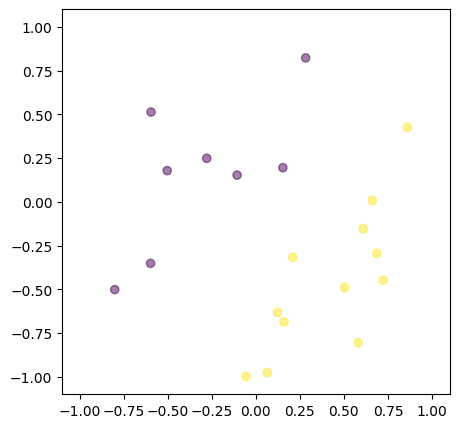

In [32]:
import numpy as np
import matplotlib.pyplot as plt

def createDataset(n=20, vector=[1,-1]):
  X = np.random.uniform(size=(n,2))*2-1
  y = (X@vector>0)*2-1
  return X, y

X, y = createDataset()

def plotDataset(X, y):
  plt.figure(figsize=(5,5))
  plt.scatter(X[:,0], X[:,1], c=y, cmap="viridis", alpha=0.5)
  plt.xlim(-1.1, 1.1)
  plt.ylim(-1.1, 1.1)

plotDataset(X, y)
plt.show()

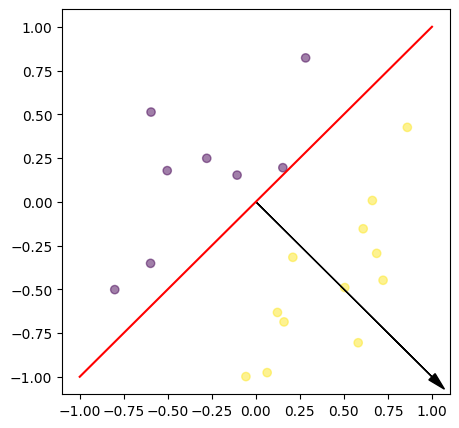

In [33]:
def plotHyperplan(vector):
  xs = np.array([-1,1])
  ys = -(vector[0]*xs/vector[1])
  plt.plot(xs, ys, 'r')

def plotVector(vector):
  plt.arrow(0, 0, vector[0], vector[1], head_width=0.05, head_length=0.1, fc='k', ec='k')

plotDataset(X, y)
vector = [1,-1]
plotHyperplan(vector)
plotVector(vector)
plt.show()

In [35]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

def sign(a):
  return (a>0)*2-1

class DummyClassifier(BaseEstimator, ClassifierMixin):
  def fit(self, X, y):
    self.w = np.array([1,-1])
    return self
  def predict(self, X):
    logits = X@self.w
    y_pred = sign(logits)
    return y_pred

clf = DummyClassifier()
clf.fit(X, y)
y_pred = clf.predict(X)
print(accuracy_score(y, y_pred))


1.0


Accuracy: 1.0
Weights: [ 0.95807391 -1.23314178]


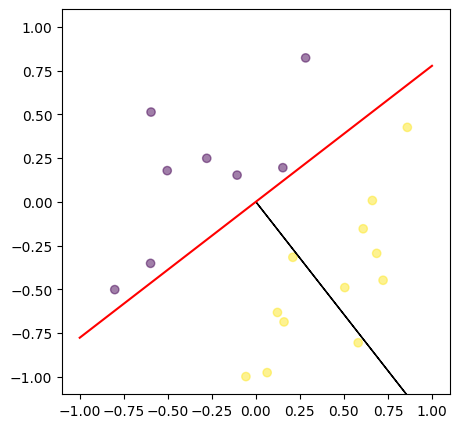

In [72]:
class PLA(BaseEstimator, ClassifierMixin):
  def __init__(self, max_iter=10):
    self.max_iter = max_iter

  def fit(self, X, y):
    self.w = np.random.uniform(size=(X.shape[1],))
    # PLA - Perceptron Learning Algorithm
    for _ in range(self.max_iter):
      cost = 0
      idx = np.arange(X.shape[0])
      np.random.shuffle(idx)
      for i in idx:
        y_pred = self.predict(X[i:i+1])
        error = y[i] - y_pred
        if error != 0:
          cost += error**2
          self.w += error*X[i]
      if cost == 0:
        break
    return self

  def predict(self, X):
    logits = X@self.w
    y_pred = sign(logits)
    return y_pred

clf = PLA()
clf.fit(X, y)
y_pred = clf.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
print(f"Weights: {clf.w}")

plotDataset(X, y)
plotHyperplan(clf.w)
plotVector(clf.w)
plt.show()


Accuracy: 0.948


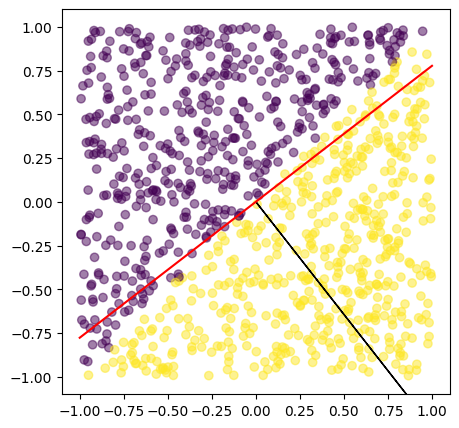

In [73]:
X_test, y_test = createDataset(1000)
y_pred = clf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
plotDataset(X_test, y_test)
plotHyperplan(clf.w)
plotVector(clf.w)
plt.show()